# Classification Assignment
## Heart Failure Prediction
**Student:** Murtaza Ali | **SMIT AIDS 2026 | Assignment 8b**


### Step 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

print("Libraries imported successfully!")


Libraries imported successfully!


### Step 2: Load and Analyze the Dataset


In [2]:
# Load dataset
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

print("Shape:", df.shape)
print()
df.head()


Shape: (299, 13)



,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
# Dataset info - datatypes and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
# Statistical summary
df.describe()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


### Step 3: Check and Handle Missing Values


In [5]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())
print()
print(f"Total missing values: {df.isnull().sum().sum()}")
# No missing values found in this dataset


Missing values in each column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Total missing values: 0


### Step 4: Encoding (if required)


In [6]:
# Check data types
print("Column dtypes:")
print(df.dtypes)
print()
# All columns are already numeric (int/float), so no encoding is needed
print("All features are numeric. No encoding required.")


Column dtypes:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

All features are numeric. No encoding required.


### Step 5: Explore Target Variable (Class Distribution)


Class Distribution:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Percentage:
DEATH_EVENT
0    67.89
1    32.11
Name: proportion, dtype: float64


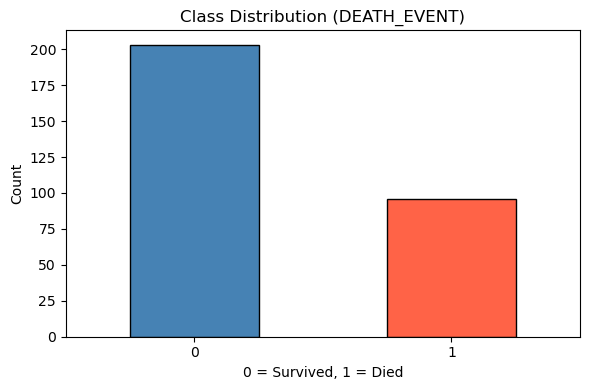


Dataset is IMBALANCED. SMOTE will be applied.


In [7]:
# Target column: DEATH_EVENT (0 = Survived, 1 = Died)
print("Class Distribution:")
print(df['DEATH_EVENT'].value_counts())
print()
print("Percentage:")
print(df['DEATH_EVENT'].value_counts(normalize=True).mul(100).round(2))

# Plot class distribution
plt.figure(figsize=(6, 4))
df['DEATH_EVENT'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Class Distribution (DEATH_EVENT)')
plt.xlabel('0 = Survived, 1 = Died')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nDataset is IMBALANCED. SMOTE will be applied.")


### Step 6: Correlation Heatmap


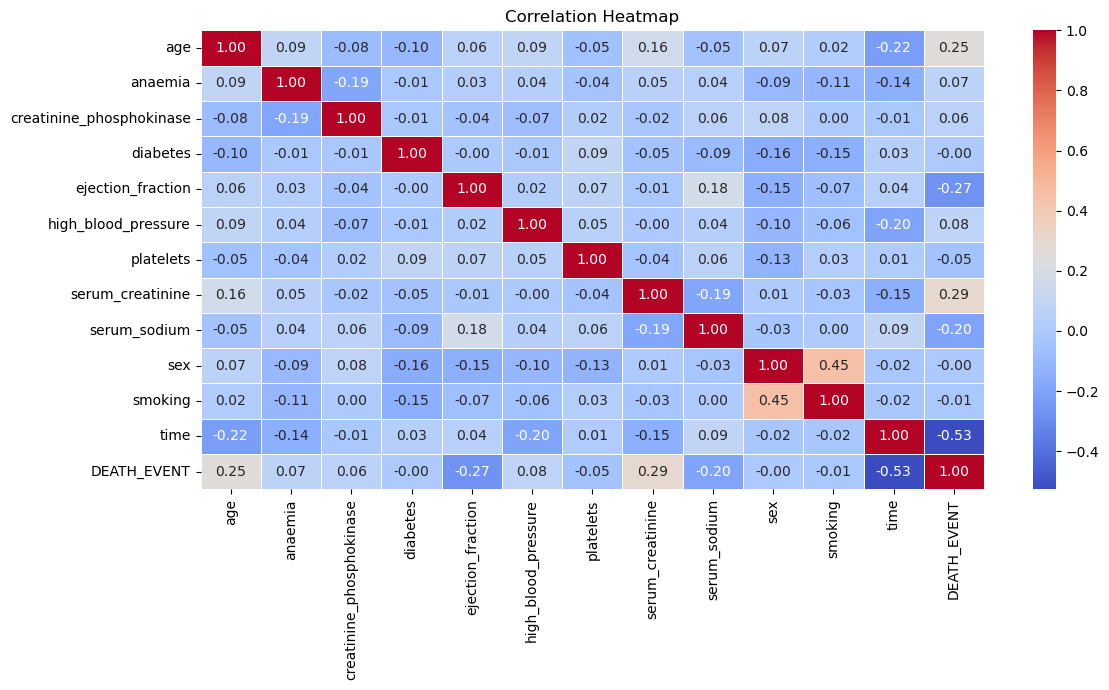

In [8]:
plt.figure(figsize=(12, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### Step 7: Feature Scaling and Train-Test Split


In [9]:
# Separate features and target
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Train-Test Split (80% train, 20% test) - stratified to keep class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 239
Testing samples:  60


In [10]:
# Feature Scaling - StandardScaler
# Important for models like SVM, KNN, Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)        # only transform test

print("Feature scaling applied using StandardScaler.")


Feature scaling applied using StandardScaler.


### Step 8: Handle Imbalanced Dataset using SMOTE


Before SMOTE: {0: np.int64(162), 1: np.int64(77)}
After  SMOTE: {np.int64(0): np.int64(162), np.int64(1): np.int64(162)}


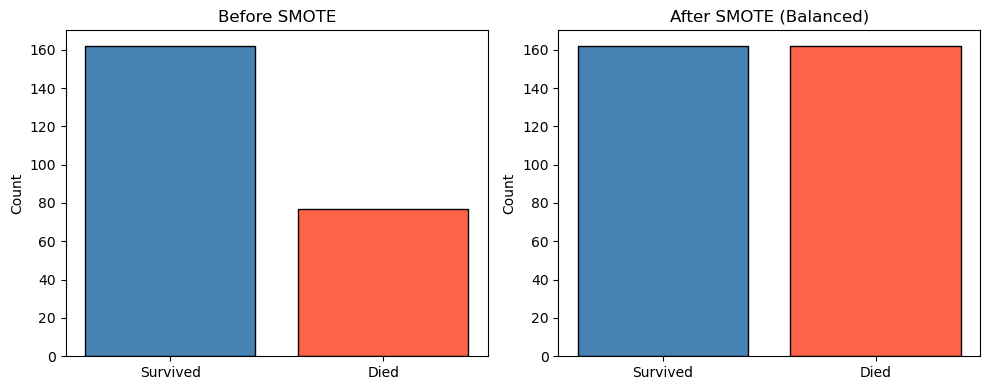

In [11]:
# Apply SMOTE only on training data (never on test data)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", dict(y_train.value_counts()))
print("After  SMOTE:", dict(zip(*np.unique(y_train_res, return_counts=True))))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Survived', 'Died'], y_train.value_counts().values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

after_counts = dict(zip(*np.unique(y_train_res, return_counts=True)))
axes[1].bar(['Survived', 'Died'], [after_counts[0], after_counts[1]],
            color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('After SMOTE (Balanced)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


### Step 9: Apply Different Classification Models


In [12]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(random_state=42),
    'KNN':                 KNeighborsClassifier(),
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_res, y_train_res)
    
    # Predict on test set
    y_pred = model.predict(X_test_scaled)
    
    # Store metrics
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
    }

print("All models trained successfully!")


All models trained successfully!


### Step 10: Accuracy, Precision, Recall, F1-Score Comparison


In [13]:
# Show comparison table
results_df = pd.DataFrame(results).T
print("=== Model Performance Comparison ===")
results_df


=== Model Performance Comparison ===


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.8000,0.7333,0.5789,0.6471
Decision Tree,0.7833,0.6250,0.7895,0.6977
Random Forest,0.8167,0.7222,0.6842,0.7027
Gradient Boosting,0.8000,0.6667,0.7368,0.7000
SVM,0.7333,0.5882,0.5263,0.5556
KNN,0.7500,0.6111,0.5789,0.5946


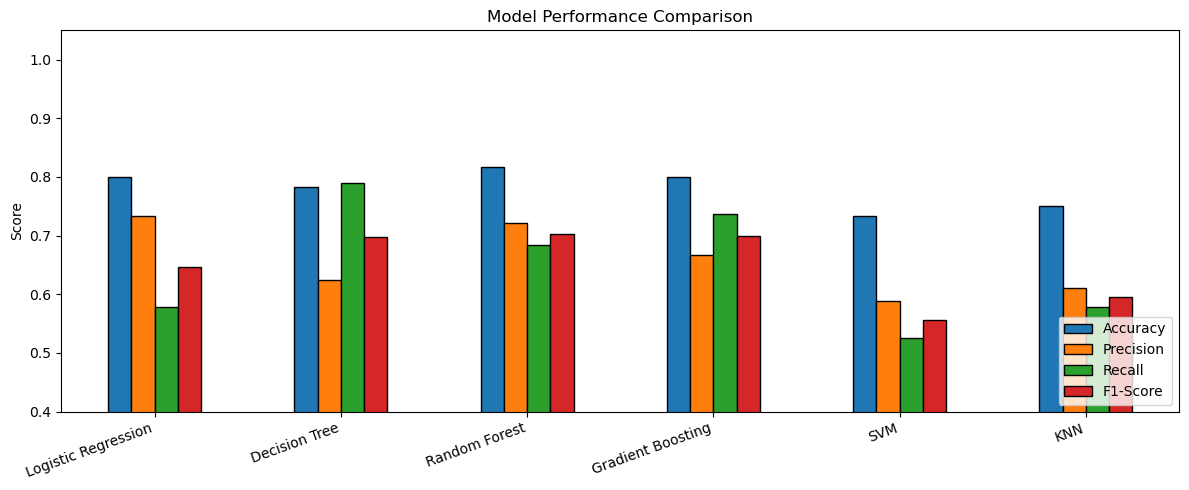

In [14]:
# Bar chart comparison
results_df.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.4, 1.05)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Step 11: Classification Report and Confusion Matrix



  Logistic Regression
              precision    recall  f1-score   support

    Survived       0.82      0.90      0.86        41
        Died       0.73      0.58      0.65        19

    accuracy                           0.80        60
   macro avg       0.78      0.74      0.75        60
weighted avg       0.79      0.80      0.79        60



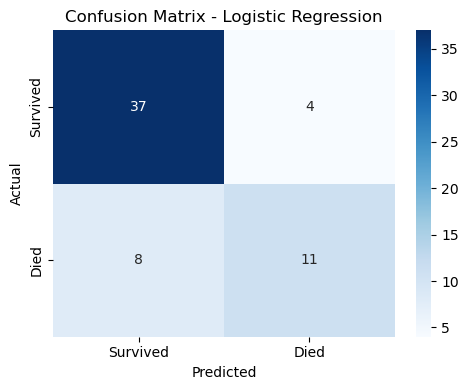


  Decision Tree
              precision    recall  f1-score   support

    Survived       0.89      0.78      0.83        41
        Died       0.62      0.79      0.70        19

    accuracy                           0.78        60
   macro avg       0.76      0.78      0.76        60
weighted avg       0.81      0.78      0.79        60



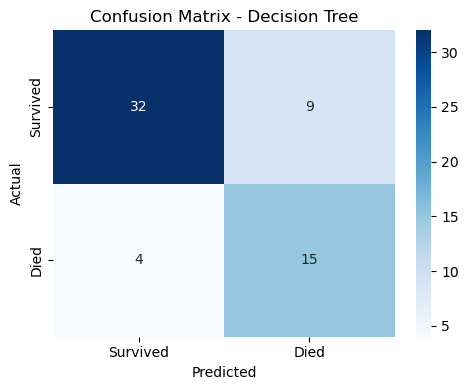


  Random Forest
              precision    recall  f1-score   support

    Survived       0.86      0.88      0.87        41
        Died       0.72      0.68      0.70        19

    accuracy                           0.82        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.81      0.82      0.82        60



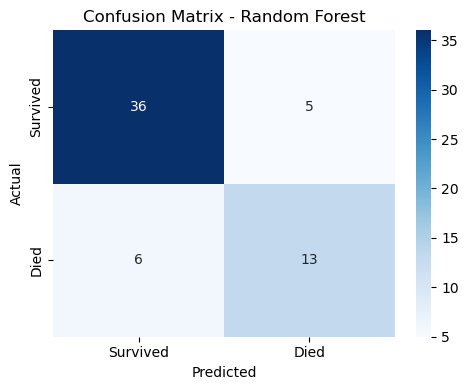


  Gradient Boosting
              precision    recall  f1-score   support

    Survived       0.87      0.83      0.85        41
        Died       0.67      0.74      0.70        19

    accuracy                           0.80        60
   macro avg       0.77      0.78      0.77        60
weighted avg       0.81      0.80      0.80        60



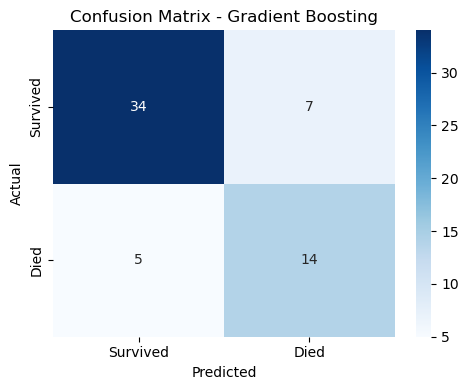


  SVM
              precision    recall  f1-score   support

    Survived       0.79      0.83      0.81        41
        Died       0.59      0.53      0.56        19

    accuracy                           0.73        60
   macro avg       0.69      0.68      0.68        60
weighted avg       0.73      0.73      0.73        60



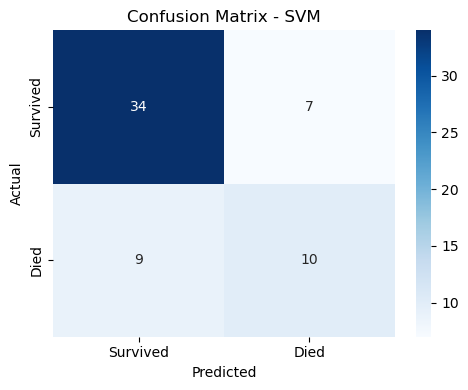


  KNN
              precision    recall  f1-score   support

    Survived       0.81      0.83      0.82        41
        Died       0.61      0.58      0.59        19

    accuracy                           0.75        60
   macro avg       0.71      0.70      0.71        60
weighted avg       0.75      0.75      0.75        60



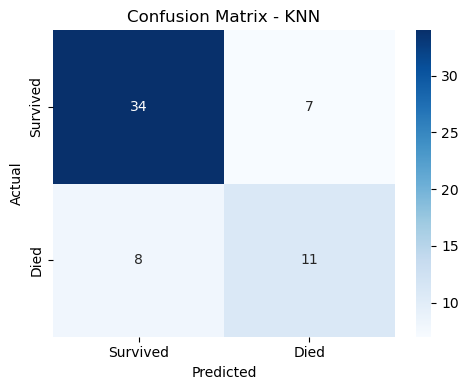

In [15]:
# Print classification report and confusion matrix for each model
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Survived', 'Died'],
                yticklabels=['Survived', 'Died'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


### Step 12: Select Best Performing Model


In [16]:
# Select best model based on F1-Score
best_model_name = results_df['F1-Score'].idxmax()
best_f1         = results_df['F1-Score'].max()

print(f"Best Model  : {best_model_name}")
print(f"F1-Score    : {best_f1}")
print()
print("Full scores for best model:")
print(results_df.loc[best_model_name])


Best Model  : Random Forest
F1-Score    : 0.7027

Full scores for best model:
Accuracy     0.8167
Precision    0.7222
Recall       0.6842
F1-Score     0.7027
Name: Random Forest, dtype: float64


### Step 13: Hyperparameter Tuning (GridSearchCV)


In [17]:
# Hyperparameter tuning for Random Forest
print("Tuning Random Forest...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_res, y_train_res)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")


Tuning Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits



Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-Score: 0.8897


=== Tuned Random Forest - Test Set Performance ===

Accuracy  : 0.8167
Precision : 0.7222
Recall    : 0.6842
F1-Score  : 0.7027

Classification Report:
              precision    recall  f1-score   support

    Survived       0.86      0.88      0.87        41
        Died       0.72      0.68      0.70        19

    accuracy                           0.82        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.81      0.82      0.82        60



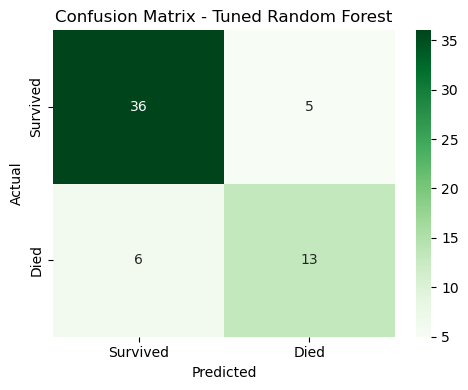

In [18]:
# Evaluate tuned model on test set
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

print("=== Tuned Random Forest - Test Set Performance ===")
print()
print(f"Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_tuned):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Survived', 'Died']))

# Confusion Matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


### Step 14: Before vs After Tuning Comparison


Base RF vs Tuned RF:
          Accuracy  Precision  Recall  F1-Score
Base RF     0.8167     0.7222  0.6842    0.7027
Tuned RF    0.8167     0.7222  0.6842    0.7027


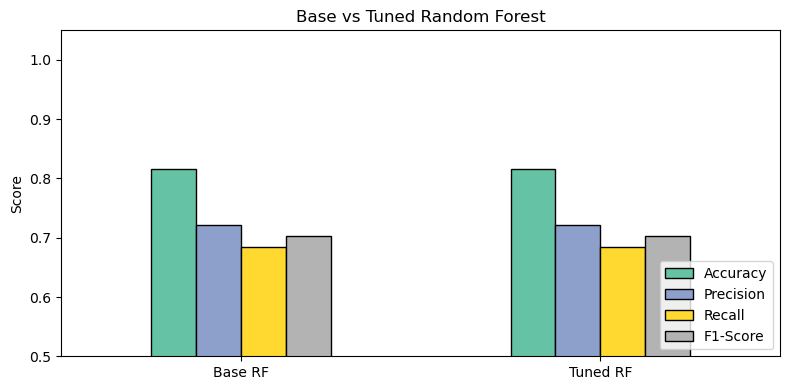

In [19]:
# Compare base Random Forest vs Tuned Random Forest
base_rf = models['Random Forest']
y_pred_base = base_rf.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Base RF': {
        'Accuracy':  round(accuracy_score(y_test, y_pred_base), 4),
        'Precision': round(precision_score(y_test, y_pred_base), 4),
        'Recall':    round(recall_score(y_test, y_pred_base), 4),
        'F1-Score':  round(f1_score(y_test, y_pred_base), 4),
    },
    'Tuned RF': {
        'Accuracy':  round(accuracy_score(y_test, y_pred_tuned), 4),
        'Precision': round(precision_score(y_test, y_pred_tuned), 4),
        'Recall':    round(recall_score(y_test, y_pred_tuned), 4),
        'F1-Score':  round(f1_score(y_test, y_pred_tuned), 4),
    }
}).T

print("Base RF vs Tuned RF:")
print(comparison)

comparison.plot(kind='bar', figsize=(8, 4), edgecolor='black', colormap='Set2')
plt.title('Base vs Tuned Random Forest')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Conclusion

| Step | What was done |
|---|---|
| Dataset Analysis | Shape, info, describe, dtypes |
| Missing Values | Checked - none found |
| Encoding | Not needed - all features numeric |
| Feature Scaling | StandardScaler applied |
| Class Imbalance | Balanced using SMOTE |
| Models Applied | LR, DT, RF, GB, SVM, KNN |
| Evaluation | Accuracy, Precision, Recall, F1, Classification Report, Confusion Matrix |
| Best Model | Selected by F1-Score |
| Hyperparameter Tuning | GridSearchCV on Random Forest |

**Assignment completed successfully!**
